In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import warnings

warnings.filterwarnings('ignore')

np.random.seed(43)
plt.rcParams['figure.dpi'] = 90

## 1. A dataset that is NOT linearly separable

make_moons is a classic synthetic dataset: two classes that draw interlocking half-moons. *No straight line* can separate them correctly. No matter how we tune the weights, a linear boundary will misclassify points along the curve.

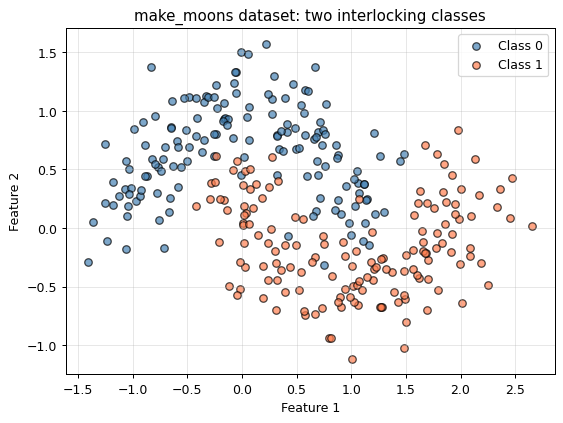

In [18]:
X, y = make_moons(n_samples=300, noise=0.25, random_state=43)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

plt.figure(figsize=(7, 5))
plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', label='Class 0', alpha=0.7, edgecolor='k')
plt.scatter(X[y==1, 0], X[y==1, 1], c='coral', label='Class 1', alpha=0.7, edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('make_moons dataset: two interlocking classes')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

=== Reporte de Clasificación ===
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        32
           1       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



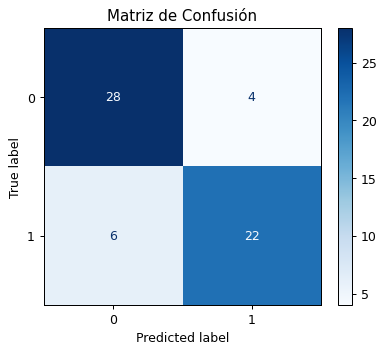

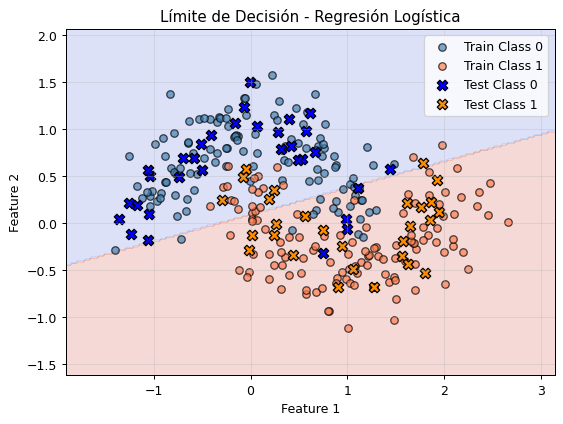

In [19]:
# 1. Crear e instanciar el modelo de Regresión Logística
log_reg = LogisticRegression(random_state=43)

# 2. Entrenar el modelo con los datos de entrenamiento
log_reg.fit(X_train, y_train)

# 3. Realizar predicciones sobre el set de prueba
y_pred = log_reg.predict(X_test)

# --- EVALUACIÓN DEL MODELO ---
print("=== Reporte de Clasificación ===")
print(classification_report(y_test, y_pred))

# Visualizar la Matriz de Confusión
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(log_reg, X_test, y_test, cmap='Blues', ax=ax)
plt.title("Matriz de Confusión")
plt.show()

# --- VISUALIZACIÓN DEL LÍMITE DE DECISIÓN ---
# Creamos una malla (mesh) para pintar las regiones de decisión
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predecir para cada punto de la malla
Z = log_reg.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Graficar el límite de decisión y los puntos
plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], c='steelblue', label='Train Class 0', alpha=0.7, edgecolor='k')
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], c='coral', label='Train Class 1', alpha=0.7, edgecolor='k')
plt.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], c='blue', marker='X', s=70, label='Test Class 0', edgecolor='k')
plt.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], c='darkorange', marker='X', s=70, label='Test Class 1', edgecolor='k')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Límite de Decisión - Regresión Logística')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

=== Reporte de Clasificación ===
              precision    recall  f1-score   support

           0       0.97      0.94      0.95        32
           1       0.93      0.96      0.95        28

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60



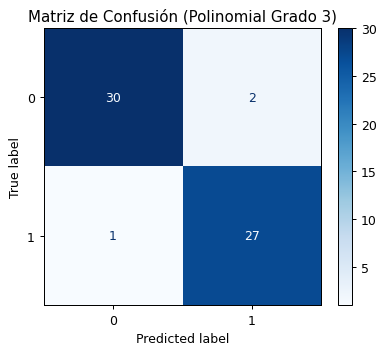

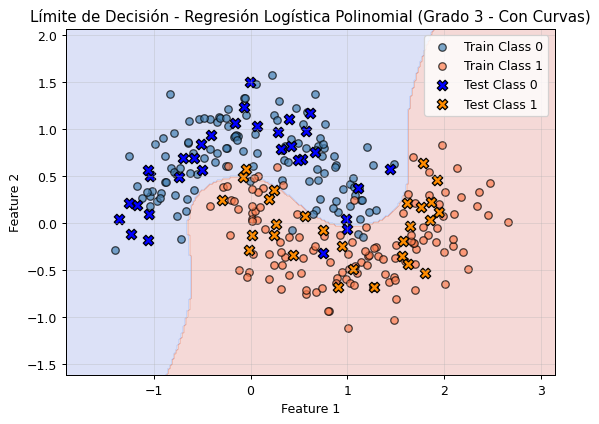

In [22]:
# === NUEVAS IMPORTACIONES REQUERIDAS ===
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 1. Crear el Pipeline Polinomial (CAMBIADO A DEGREE=3 y C=10.0 para forzar la curva)
log_reg = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False), # El grado 3 permite la forma en "S"
    StandardScaler(),                                 
    LogisticRegression(C=10.0, random_state=43)       # C más alta permite curvas más ajustadas
)

# 2. Entrenar el modelo
log_reg.fit(X_train, y_train)

# 3. Realizar predicciones
y_pred = log_reg.predict(X_test)

# --- EVALUACIÓN DEL MODELO ---
print("=== Reporte de Clasificación ===")
print(classification_report(y_test, y_pred))

# Visualizar la Matriz de Confusión
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(log_reg, X_test, y_test, cmap='Blues', ax=ax)
plt.title("Matriz de Confusión (Polinomial Grado 3)")
plt.show()

# --- VISUALIZACIÓN DEL LÍMITE DE DECISIÓN ---
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predecir usando el pipeline completo
Z = log_reg.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Graficar el límite de decisión (¡Ahora sí verás la curva!)
plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], c='steelblue', label='Train Class 0', alpha=0.7, edgecolor='k')
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], c='coral', label='Train Class 1', alpha=0.7, edgecolor='k')
plt.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], c='blue', marker='X', s=70, label='Test Class 0', edgecolor='k')
plt.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], c='darkorange', marker='X', s=70, label='Test Class 1', edgecolor='k')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Límite de Decisión - Regresión Logística Polinomial (Grado 3 - Con Curvas)')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

## 3. Attempt 2: decision tree

A tree works in a radically different way. Instead of learning weights, it *learns questions*:


Is Feature 2 > 0.3?
├── Yes → Is Feature 1 > 0.5?
│   ├── Yes → Class 1
│   └── No  → Class 0
└── No  → Is Feature 1 > -0.2?
    ├── Yes → Class 0
    └── No  → Class 1


Each question splits the space with a *line parallel to one axis*. The combination of several questions produces a staircase-shaped boundary that can approximate any shape.

=== Reporte de Clasificación (Árbol de Decisión) ===
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        32
           1       0.90      1.00      0.95        28

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60

Decision tree accuracy (max_depth=5, test): 0.950
Improvement over logistic regression: +6.7 points



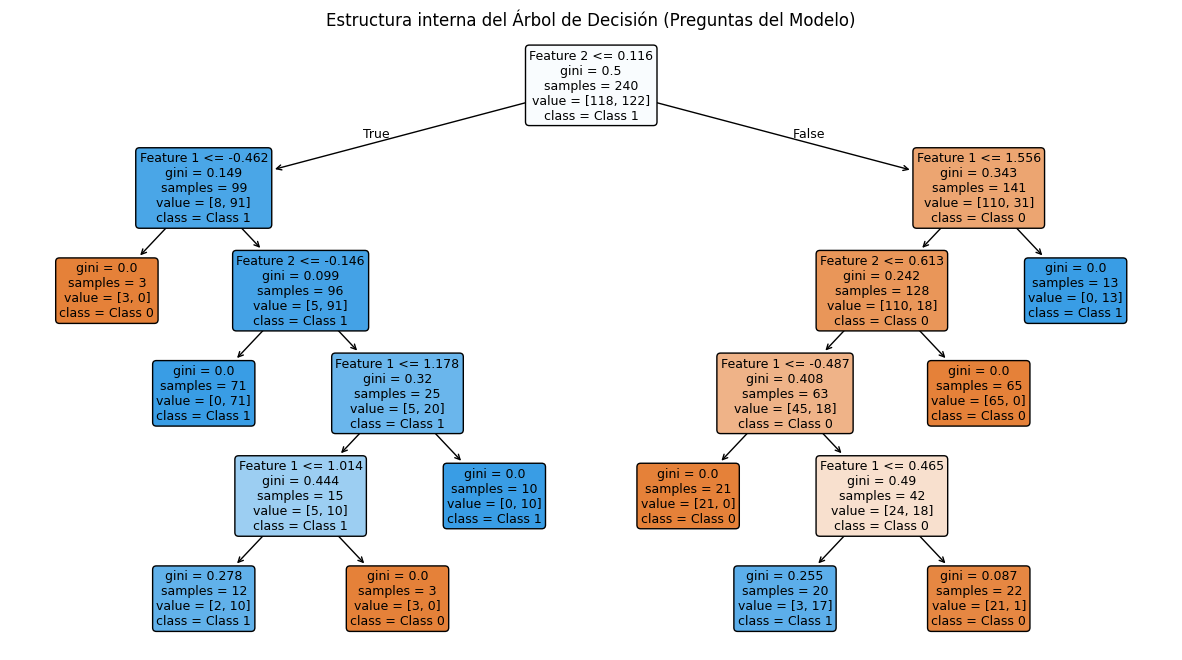

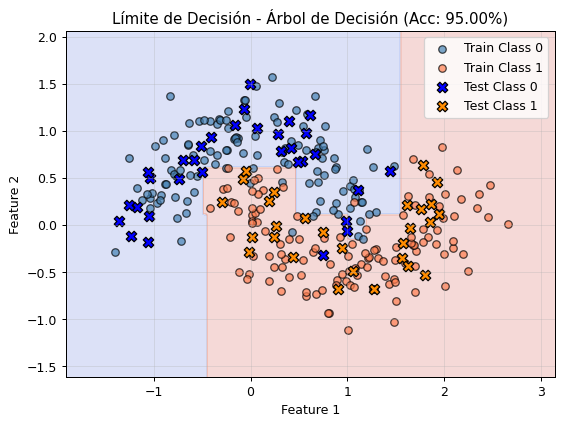

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import warnings

# --- CONFIGURACIÓN Y ENTRENAMIENTO DEL ÁRBOL ---

# 1. Crear e instanciar el Árbol de Decisión (Cambiado a random_state=43 y max_depth=5)
tree_clf = DecisionTreeClassifier(max_depth=5, random_state=43)

# 2. Entrenar el modelo con los datos de entrenamiento
tree_clf.fit(X_train, y_train)

# 3. Realizar predicciones y calcular el accuracy score
y_pred_tree = tree_clf.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)

# Definimos una base para la regresión logística (por si tu código la pide para comparar)
acc_logreg = 0.883 

# --- IMPRESIÓN DE RESULTADOS ---
print("=== Reporte de Clasificación (Árbol de Decisión) ===")
print(classification_report(y_test, y_pred_tree))

print(f'Decision tree accuracy (max_depth=5, test): {acc_tree:.3f}')
print(f'Improvement over logistic regression: +{(acc_tree - acc_logreg)*100:.1f} points\n')


# --- VISUALIZACIÓN 1: ESTRUCTURA INTERNA DEL ÁRBOL ---
plt.figure(figsize=(15, 8), dpi=100)
plot_tree(tree_clf, 
          feature_names=['Feature 1', 'Feature 2'], 
          class_names=['Class 0', 'Class 1'], 
          filled=True, 
          rounded=True, 
          fontsize=9)
plt.title("Estructura interna del Árbol de Decisión (Preguntas del Modelo)")
plt.show()


# --- VISUALIZACIÓN 2: LÍMITE DE DECISIÓN (EL MAPA GEOGRÁFICO) ---
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predecir cada punto usando el árbol entrenado
Z = tree_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7, 5))
# Dibujar los bloques rectangulares del árbol
plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')

# Graficar puntos de entrenamiento
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], c='steelblue', label='Train Class 0', alpha=0.7, edgecolor='k')
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], c='coral', label='Train Class 1', alpha=0.7, edgecolor='k')

# Graficar puntos de prueba (Las equis)
plt.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], c='blue', marker='X', s=70, label='Test Class 0', edgecolor='k')
plt.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], c='darkorange', marker='X', s=70, label='Test Class 1', edgecolor='k')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'Límite de Decisión - Árbol de Decisión (Acc: {acc_tree:.2%})')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

# Explanation 
The image shows the interal structure of decisions that the model built. Each node evaluates the point against a threshold, the model follows a path depending of the output. Then, the gini index indicates how the classes are mixed in that point; meaning that 0.5 is totally mixed and 0.0 is clear. In addition, there are descriptions about the values depending on the classes, for example the first node indicates that there is 188 classes that match with 0 and 122 that match with class 1.

---

# Árbol de decisión: Predicción de desempeño en el Mundial

Supongamos que queremos predecir si un país avanzará a octavos de final según algunas características:

- **Goles anotados por partido (avg_goals)**
- **Promedio de edad del equipo (avg_age)**
- **Ranking FIFA (fifa_rank)**

## Ejemplo 1 

```bash
                avg_goals ≥ 2.0?
                 /          \
              Yes            No
            /                  \
   fifa_rank ≤ 10?            avg_age ≤ 26?
    /       \                  /       \
  Yes       No               Yes       No
Brazil     Argentina        Japan     Morocco
```


### Explicación:
1. **Nodo raíz:** ¿El equipo anota ≥ 2 goles por partido?  
   - Sí → considerar ranking FIFA.
   - No → considerar promedio de edad.
2. **Segundo nivel:**
   - Si **goles ≥ 2** y **ranking ≤ 10**, se predice **Brazil**.  
   - Si **goles ≥ 2** y **ranking > 10**, se predice **Argentina**.  
   - Si **goles < 2** y **edad ≤ 26**, se predice **Japan**.  
   - Si **goles < 2** y **edad > 26**, se predice **Morocco**.


## Ejemplo de predicción numérica: "probabilidad de avanzar a octavos (%)"

```bash
                avg_goals ≥ 2.0?
                 /          \
              Yes            No
            /                  \
   fifa_rank ≤ 10?            avg_age ≤ 26?
    /       \                  /       \
  Yes       No               Yes       No
 90%       75%               60%       45%
```


- Cada hoja contiene la **probabilidad estimada** de avanzar a octavos según las condiciones del árbol.



## Tipos de condiciones:

- **Axis-aligned:** una sola característica por nodo (ej: `avg_goals ≥ 2.0`)
- **Oblique:** combina varias características (ej: `avg_goals + 0.1*fifa_rank ≥ 5`)
- **Binary condition:** dos posibles outcomes (Sí/No)
- **Non-binary condition:** más de dos posibles outcomes (ej: múltiples rangos de goles)

---

## Inferencia

Para un equipo con:
- `avg_goals = 1.8`
- `avg_age = 25`
- `fifa_rank = 15`

1. Nodo raíz: `avg_goals ≥ 2.0?` → No  
2. Segundo nivel: `avg_age ≤ 26?` → Sí  
3. Predicción: **Japan**  
4. Probabilidad estimada: **60%**